# Compute morphological features on real data

In [2]:
# import packages
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import nibabel as nib
from cvtub.utils import slices, load_nii
from morphometrics import load_nii, compute_morphometrics, glcm_summary, lbp_summary
import time
from tqdm import tqdm
import pickle 
import random
from concurrent.futures import ProcessPoolExecutor
import SimpleITK as sitk
from skimage import filters
import math
import pandas as pd
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import normalize

if torch.cuda.is_available():
    dtype = torch.cuda.FloatTensor 
else:
    dtype = torch.FloatTensor

### Import data

- Dataset 5 - CTRL 
- Dataset 19 - EARLY
- Dataset 8 - LATE

In [3]:
ctrl_sample = []
ctrl_filename = "Dataset_5"
ctrl_filetags = [27,28,29,33,34,37]
for i in range(len(ctrl_filetags)):
    ctrl_sample.append(load_nii(ctrl_filename + "/" + ctrl_filename + "_tile_" + str(ctrl_filetags[i]) + ".nii.gz"))
    
early_sample = []
early_filename = "Dataset_19"
early_filetags = [5,8,11,12,13,14]
for i in range(len(early_filetags)):
    early_sample.append(load_nii(early_filename + "/" + early_filename + "_tile_" + str(early_filetags[i]) + ".nii.gz"))

late_sample = []
late_filename = "Dataset_8"
late_filetags = [4,11,12,14]
for i in range(len(late_filetags)):
    late_sample.append(load_nii(late_filename + "/" + late_filename + "_tile_" + str(late_filetags[i]) + ".nii.gz"))

In [4]:
# check size of data
print("CTRL: ", [data.shape for data in ctrl_sample])
print("EARLY: ", [data.shape for data in early_sample])
print("LATE: ",[data.shape for data in late_sample])

CTRL:  [(58, 2360, 2360), (58, 2360, 2360), (58, 2360, 2360), (58, 2360, 2360), (58, 2360, 2360), (58, 2360, 2360)]
EARLY:  [(91, 2304, 2304), (91, 2304, 2304), (91, 2304, 2304), (91, 2304, 2304), (91, 2304, 2304), (91, 2304, 2304)]
LATE:  [(52, 2304, 2304), (52, 2304, 2304), (52, 2304, 2304), (52, 2304, 2304)]


Smooth and segment image for later applications

In [5]:
def smooth_and_segment(image):
    image_sitk_smoothed = sitk.GetImageFromArray(image)
    image_sitk_smoothed = sitk.SmoothingRecursiveGaussian(image_sitk_smoothed, 1)
    smoothed_image = sitk.GetArrayFromImage(image_sitk_smoothed)
    thresh = filters.threshold_otsu(smoothed_image)
    return smoothed_image-thresh

for i in range(len(ctrl_sample)):
    ctrl_sample[i] = smooth_and_segment(ctrl_sample[i])
    
for i in range(len(early_sample)):
    early_sample[i] = smooth_and_segment(early_sample[i])
    
for i in range(len(late_sample)):
    late_sample[i] = smooth_and_segment(late_sample[i])

Take samples from data and compute the various measures

In [ ]:
def take_samples(data_list, n):
    # from the list of tiled images extract n samples 
    n_samples = len(data_list)
    subsample_num = n//n_samples # number of subsamples to take from each
    remainder = n%n_samples # take the remaining from the last element in the list
    if remainder==0:
        num_samples = [subsample_num for i in range(n_samples)]
    else:
        num_samples = [subsample_num for i in range(n_samples-1)] + [subsample_num+remainder]
    
    list_samples = []
    patch_length = 500
    extracted_patches = []
    # take non-overlapping samples
    for i in range(n_samples):
        current = data_list[i]
        h, n, m = current.shape
        sample_size = num_samples[i]
        # determine origins of samples
        # to get x and y origins - first list possible origins
        possible_xy_origins = []
        for x_start in range(0, n - patch_length + 1, patch_length):
            for y_start in range(0, m - patch_length + 1, patch_length):
                possible_xy_origins.append((x_start, y_start))
        # take height origin as any number between 0 and h-50
        height_origin = [random.randint(0, (h-50-1)) for t in range(sample_size*5)]
        if len(possible_xy_origins) < sample_size:
            print(f"  Warning: Only {len(possible_xy_origins)} non-overlapping patches are possible, but {sample_size} were requested. "
                  f"Returning all {len(possible_xy_origins)} possible patches.")
            selected_origins = possible_xy_origins
        else:
            selected_origins = random.sample(possible_xy_origins, min(sample_size*5, len(possible_xy_origins)))
        # sample 3 times as much such that if we sample regions which are outside the bone then we move onto the next sample
        
        sub_extracted_patches = []
        ind_count = 0
        while len(sub_extracted_patches)<sample_size:
            if ind_count > sample_size*3:
                print("more than 3 times sample")
            patch = current[height_origin[ind_count] : height_origin[ind_count] + 50,
                           selected_origins[ind_count][0] : selected_origins[ind_count][0] + patch_length,
                           selected_origins[ind_count][1] : selected_origins[ind_count][1] + patch_length]
            if np.sum(patch>=0)/patch.size > 0.005:
                sub_extracted_patches.append(patch)
            ind_count += 1
            
        
        extracted_patches = extracted_patches + sub_extracted_patches
        
    return extracted_patches
            

In [68]:
ctrl_samples = take_samples(ctrl_sample, 30)
early_samples = take_samples(early_sample, 30)
late_samples = take_samples(late_sample, 30)

In [69]:
ctrl_morphologies = []
print("\n--- Starting Morphometrics Computation for CTRL---")
with ProcessPoolExecutor(max_workers=100) as executor:
    # executor.map automatically handles submitting tasks and yielding results in order
    results_iterator = tqdm(executor.map(compute_morphometrics, ctrl_samples),
                            total=len(ctrl_samples),
                            desc="Calculating Morphometrics")
    for result in results_iterator:
        ctrl_morphologies.append(result)


--- Starting Morphometrics Computation for CTRL---


Calculating Morphometrics: 100%|██████████| 30/30 [02:22<00:00,  4.76s/it]


In [70]:
early_morphologies = []
print("\n--- Starting Morphometrics Computation for EARLY---")
with ProcessPoolExecutor(max_workers=100) as executor:
    # executor.map automatically handles submitting tasks and yielding results in order
    results_iterator = tqdm(executor.map(compute_morphometrics, early_samples),
                            total=len(early_samples),
                            desc="Calculating Morphometrics")
    for result in results_iterator:
        early_morphologies.append(result)


--- Starting Morphometrics Computation for EARLY---


Calculating Morphometrics: 100%|██████████| 30/30 [03:21<00:00,  6.71s/it]


In [71]:
late_morphologies = []
print("\n--- Starting Morphometrics Computation for LATE---")
with ProcessPoolExecutor(max_workers=100) as executor:
    # executor.map automatically handles submitting tasks and yielding results in order
    results_iterator = tqdm(executor.map(compute_morphometrics, late_samples),
                            total=len(late_samples),
                            desc="Calculating Morphometrics")
    for result in results_iterator:
        late_morphologies.append(result)


--- Starting Morphometrics Computation for LATE---


Calculating Morphometrics: 100%|██████████| 30/30 [00:54<00:00,  1.82s/it]


In [72]:
pickle.dump([ctrl_morphologies,early_morphologies,late_morphologies], open("real_data_morphometrics.pkl","wb"))

Compare the distributions of morphometrics across the samples


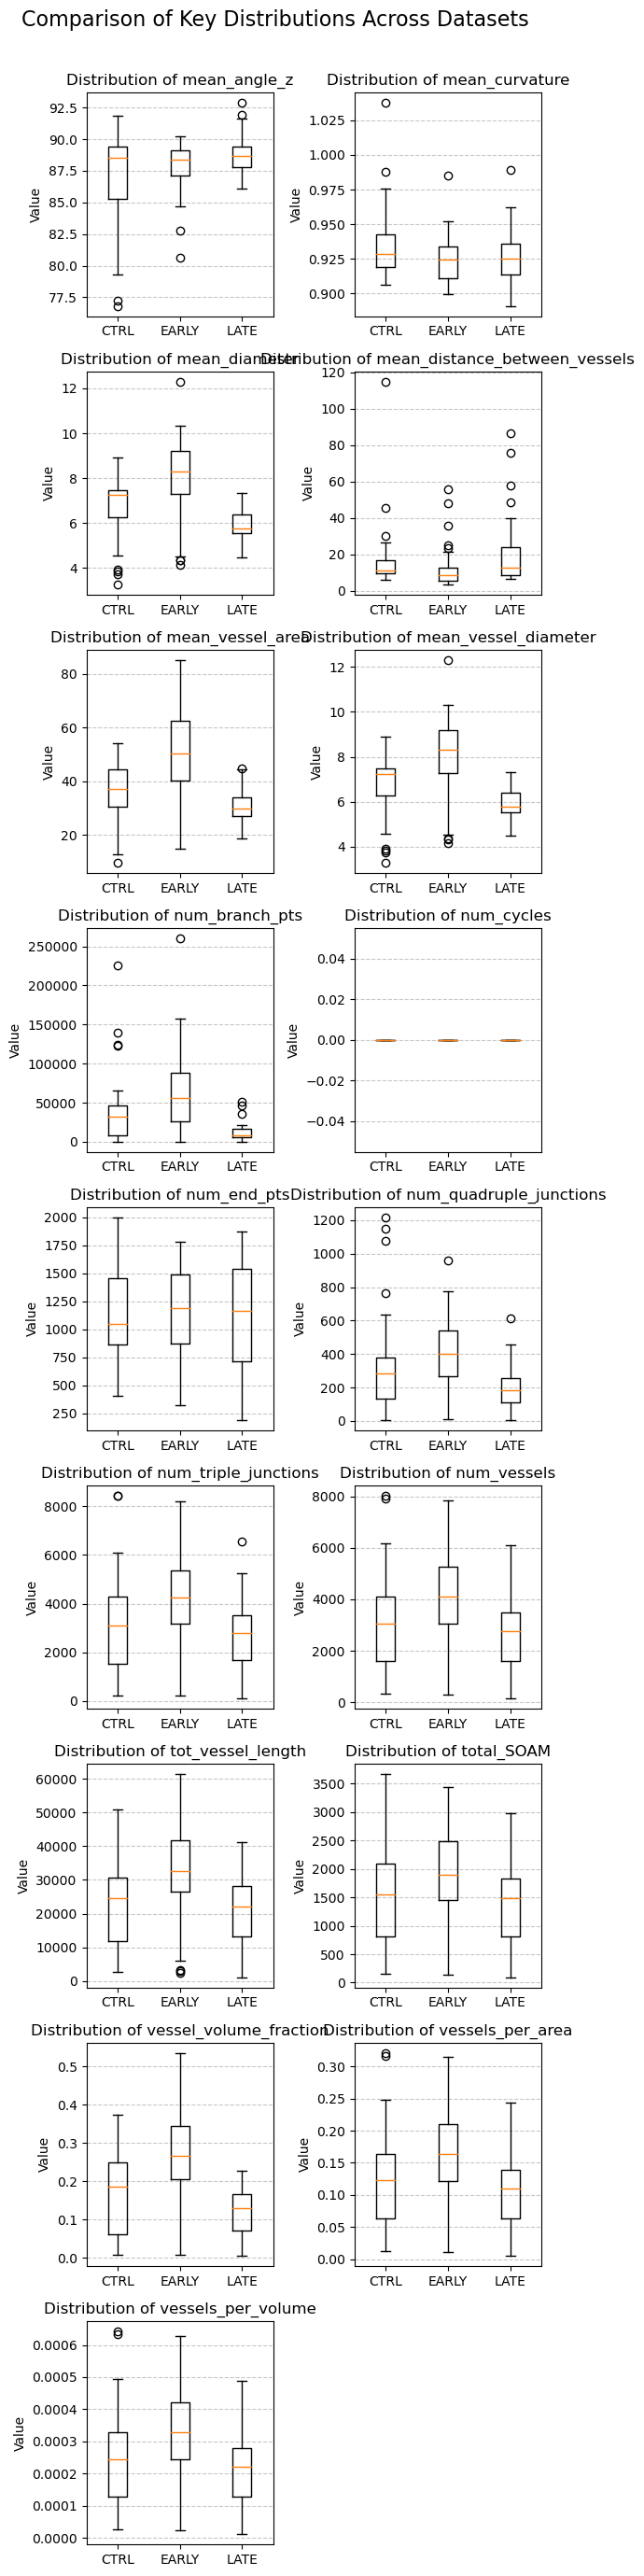

In [76]:
import math 

all_morphometric_lists = [ctrl_morphologies, early_morphologies, late_morphologies]
list_names = ["CTRL", "EARLY", "LATE"]

def plot_dictionary_boxplot_comparisons(all_data_lists, list_names):
    """
    Plots box plots for each common key across multiple lists of dictionaries.

    Args:
        all_data_lists (list of lists of dict): A list where each element is
                                                 one of your original lists of dictionaries.
        list_names (list of str): Names for each of the data lists, used for labels.
    """

    if not all_data_lists:
        print("No data lists provided.")
        return

    # 1. Determine all unique keys
    # Assuming all dictionaries within a list have the same keys, and across lists too
    # We'll take keys from the first dictionary of the first list.
    try:
        all_keys = list(all_data_lists[0][0].keys())
        all_keys.sort() # Sort keys for consistent plotting order
    except (IndexError, AttributeError):
        print("Error: Ensure all_data_lists is a list of lists of dictionaries and not empty.")
        return

    num_keys = len(all_keys)
    num_lists = len(all_data_lists)

    if num_keys == 0:
        print("No keys found in the dictionaries.")
        return

    # 2. Determine subplot layout
    # Calculate rows and columns for the subplots
    cols = 2  # You can adjust this number of columns
    rows = math.ceil(num_keys / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3), squeeze=False)
    # squeeze=False ensures axes is always a 2D array, even for a single subplot

    axes_flat = axes.flatten() # Flatten the 2D array of axes for easier iteration

    # 3. Iterate through each key and plot
    for i, key in enumerate(all_keys):
        ax = axes_flat[i] # Get the current subplot axis

        data_for_key = []
        for j, data_list in enumerate(all_data_lists):
            # Extract values for the current key from each dictionary in the list
            values = [d.get(key) for d in data_list if d.get(key) is not None]
            data_for_key.append(values)

        # Plot the box plots for the current key
        ax.boxplot(data_for_key, labels=list_names)
        ax.set_title(f'Distribution of {key}')
        ax.set_ylabel('Value')
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    # 4. Hide any unused subplots if the number of keys doesn't perfectly fill the grid
    for j in range(i + 1, len(axes_flat)):
        fig.delaxes(axes_flat[j]) # Remove empty subplots

    plt.tight_layout() # Adjust subplot parameters for a tight layout
    plt.suptitle('Comparison of Key Distributions Across Datasets', y=1.02, fontsize=16) # Overall title
    plt.show()

# Call the function with your data
plot_dictionary_boxplot_comparisons(all_morphometric_lists, list_names)

# Can test out the prediction ability

In [79]:
labels = ['CTRL'] * 30 + ['EARLY'] * 30 + ['LATE'] * 30 
# convert the list of dictionaries to dataframes
morphometric_df = pd.DataFrame(ctrl_morphologies+early_morphologies+late_morphologies)
morphometric_df.head()

,vessel_volume_fraction,mean_diameter,num_branch_pts,num_end_pts,num_vessels,tot_vessel_length,num_cycles,vessels_per_area,vessels_per_volume,mean_vessel_diameter,mean_vessel_area,mean_curvature,num_triple_junctions,num_quadruple_junctions,mean_angle_z,total_SOAM,mean_distance_between_vessels
0,0.223097,7.557778,33300,985,3480,26975,0,0.13920,0.000278,7.557778,46.161372,0.935711,3695,380,90.029764,1760.605549,10.766999
1,0.217301,7.220909,31924,1013,3404,26523,0,0.13616,0.000272,7.220909,41.011707,0.913264,3569,308,91.816840,1806.706458,10.978747
2,0.076015,6.579621,7253,849,1536,11696,0,0.06144,0.000123,6.579621,35.411108,0.913491,1511,134,85.976550,782.581627,26.421753
3,0.141674,7.408183,29539,1010,2227,17098,0,0.08908,0.000178,7.408183,44.443724,0.913999,2291,210,89.883454,1067.400958,17.834245
4,0.257887,7.266084,47453,1106,4147,33135,0,0.16588,0.000332,7.266084,37.639243,0.928765,4312,382,89.167821,2133.590913,9.147580


In [82]:
X = morphometric_df.to_numpy()
y = np.array(labels)

# -----------------------------
# Define classifiers
# -----------------------------
classifiers = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(solver='saga', max_iter=15000),
    "SVM (RBF kernel)": SVC(kernel='rbf')
}

# -----------------------------
# Cross-validate each classifier on each dataset
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for clf_name, clf in classifiers.items():
    scores = []
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        clf.fit(X_train, y_train)
        acc = clf.score(X_test, y_test)
        scores.append(acc)

    print(f"{clf_name:20s} | Avg Accuracy: {np.mean(scores):.4f}")

Random Forest        | Avg Accuracy: 0.6667
Logistic Regression  | Avg Accuracy: 0.6444
SVM (RBF kernel)     | Avg Accuracy: 0.5444
